# Missing Value Imputation in Python

This notebook introduces basic imputation methods step by step.

We start with a **very small dataset** so the logic is easy to understand.  
Then we move to a more realistic **bank/customer dataset**.

Methods covered:

1. Mean imputation  
2. Median imputation  
3. Mode imputation  
4. KNN imputation  
5. MICE-style iterative imputation  

The goal is not only to fill missing values, but also to inspect how imputation changes the data.

## 1. Setup


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

# IterativeImputer is still experimental in scikit-learn.
# This import is required before importing IterativeImputer.
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 140,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Load the simple missing-values dataset

This small dataset allows to calculate the mean manually.

For example, for `study_hours`, the non-missing values are:

`2, 4, 6, 8`

The mean is:

`(2 + 4 + 6 + 8) / 4 = 5`

In [5]:
simple_df = pd.read_csv("data/simple_missing_values_sample.csv")

simple_df

,student,study_hours,exam_score,participation
0,Ana,2.0,60.0,High
1,Ben,4.0,70.0,Medium
2,Clara,NaN,80.0,NaN
3,David,6.0,NaN,Medium
4,Emma,8.0,100.0,High
5,Felix,NaN,NaN,NaN


## 3. Identify missing values

Before imputing anything, we inspect where missing values exist.

In [6]:
simple_df.isna()

,student,study_hours,exam_score,participation
0,False,False,False,False
1,False,False,False,False
2,False,True,False,True
3,False,False,True,False
4,False,False,False,False
5,False,True,True,True


In [44]:
missing_summary = pd.DataFrame({
    "missing_count": simple_df.isna().sum(),
    "missing_percent": simple_df.isna().mean() * 100
})

missing_summary

,missing_count,missing_percent
student,0,0.000000
study_hours,2,33.333333
exam_score,2,33.333333
participation,2,33.333333


## 4. Start with one column: mean imputation for `study_hours`

Mean imputation replaces missing numeric values with the average of the available values.

Here, we start with one column only to make the logic transparent.

In [45]:
study_hours_mean = simple_df["study_hours"].mean()

print("Mean of study_hours:", study_hours_mean)

Mean of study_hours: 5.0


In [46]:
simple_mean_one_column = simple_df.copy()

simple_mean_one_column["study_hours"] = simple_mean_one_column["study_hours"].fillna(study_hours_mean)

simple_mean_one_column

,student,study_hours,exam_score,participation
0,Ana,2.0,60.0,High
1,Ben,4.0,70.0,Medium
2,Clara,5.0,80.0,NaN
3,David,6.0,NaN,Medium
4,Emma,8.0,100.0,High
5,Felix,5.0,NaN,NaN


## 5. Simple before/after metrics

We compare basic metrics before and after imputation.

Important idea:

Mean imputation often changes the variance because it inserts repeated average values.

In [47]:
comparison_one_column = pd.DataFrame({
    "before": simple_df["study_hours"].describe(),
    "after_mean_imputation": simple_mean_one_column["study_hours"].describe()
})

comparison_one_column

,before,after_mean_imputation
count,4.000000,6.00
mean,5.000000,5.00
std,2.581989,2.00
min,2.000000,2.00
25%,3.500000,4.25
50%,5.000000,5.00
75%,6.500000,5.75
max,8.000000,8.00


In [48]:
print("Variance before:", simple_df["study_hours"].var())
print("Variance after:", simple_mean_one_column["study_hours"].var())

Variance before: 6.666666666666667
Variance after: 4.0


## 6. Histogram before and after mean imputation

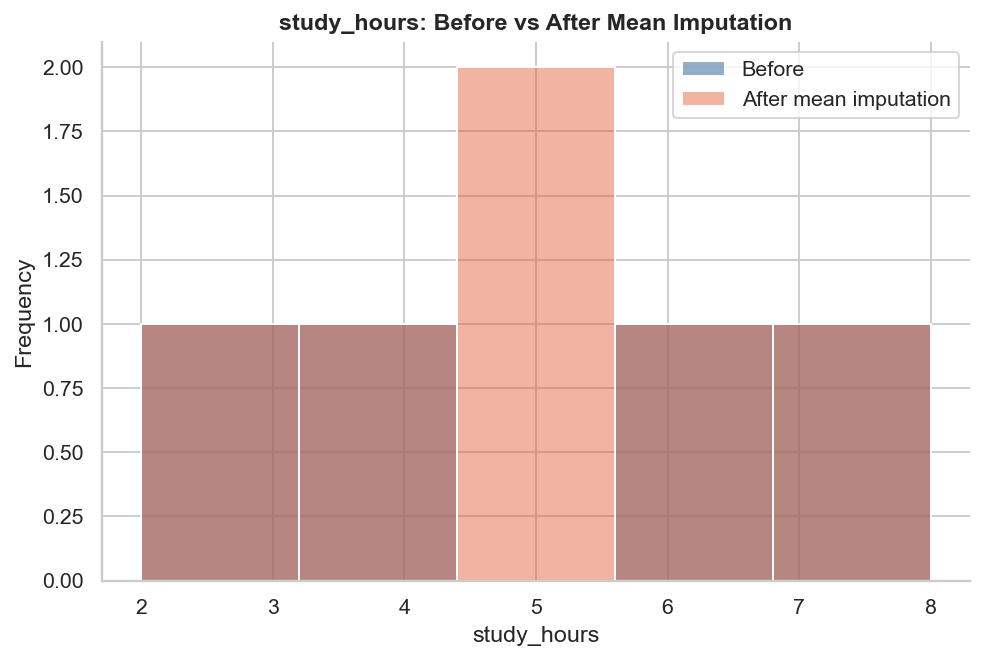

In [51]:
plt.figure(figsize=(8, 5), dpi=140)

sns.histplot(simple_df["study_hours"].dropna(), bins=5, color="#4C78A8", alpha=0.60, label="Before")
sns.histplot(simple_mean_one_column["study_hours"], bins=5, color="#E4572E", alpha=0.45, label="After mean imputation")

plt.title("study_hours: Before vs After Mean Imputation")
plt.xlabel("study_hours")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Section A — Mean Imputation

Now we apply mean imputation to all numeric columns.

For categorical columns, we leave them unchanged in this section.

In [52]:
numeric_columns_simple = simple_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns_simple = [col for col in simple_df.columns if col not in numeric_columns_simple]

print("Numeric columns:", numeric_columns_simple)
print("Categorical columns:", categorical_columns_simple)

Numeric columns: ['study_hours', 'exam_score']
Categorical columns: ['student', 'participation']


In [53]:
simple_mean = simple_df.copy()

mean_imputer = SimpleImputer(strategy="mean")
simple_mean[numeric_columns_simple] = mean_imputer.fit_transform(simple_mean[numeric_columns_simple])

simple_mean

,student,study_hours,exam_score,participation
0,Ana,2.0,60.0,High
1,Ben,4.0,70.0,Medium
2,Clara,5.0,80.0,NaN
3,David,6.0,77.5,Medium
4,Emma,8.0,100.0,High
5,Felix,5.0,77.5,NaN


In [15]:
mean_metrics = pd.DataFrame({
    "missing_before": simple_df[numeric_columns_simple].isna().sum(),
    "missing_after": simple_mean[numeric_columns_simple].isna().sum(),
    "mean_before": simple_df[numeric_columns_simple].mean(),
    "mean_after": simple_mean[numeric_columns_simple].mean(),
    "variance_before": simple_df[numeric_columns_simple].var(),
    "variance_after": simple_mean[numeric_columns_simple].var(),
})

mean_metrics

,missing_before,missing_after,mean_before,mean_after,variance_before,variance_after
study_hours,2,0,5.0,5.0,6.666667,4.0
exam_score,2,0,77.5,77.5,291.666667,175.0


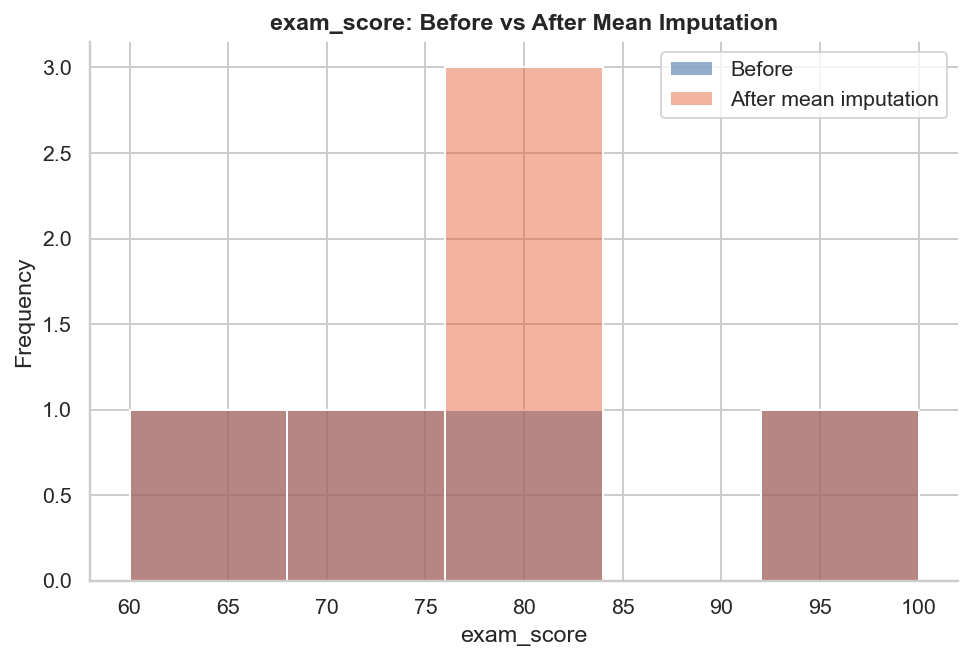

In [16]:
plt.figure(figsize=(8, 5), dpi=140)

sns.histplot(simple_df["exam_score"].dropna(), bins=5, color="#4C78A8", alpha=0.60, label="Before")
sns.histplot(simple_mean["exam_score"], bins=5, color="#E4572E", alpha=0.45, label="After mean imputation")

plt.title("exam_score: Before vs After Mean Imputation")
plt.xlabel("exam_score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Section B — Median Imputation

Median imputation replaces missing numeric values with the middle value.

This is often useful when the data is skewed or affected by outliers.

In [17]:
simple_median = simple_df.copy()

median_imputer = SimpleImputer(strategy="median")
simple_median[numeric_columns_simple] = median_imputer.fit_transform(simple_median[numeric_columns_simple])

simple_median

,student,study_hours,exam_score,participation
0,Ana,2.0,60.0,High
1,Ben,4.0,70.0,Medium
2,Clara,5.0,80.0,NaN
3,David,6.0,75.0,Medium
4,Emma,8.0,100.0,High
5,Felix,5.0,75.0,NaN


In [18]:
median_metrics = pd.DataFrame({
    "missing_before": simple_df[numeric_columns_simple].isna().sum(),
    "missing_after": simple_median[numeric_columns_simple].isna().sum(),
    "median_before": simple_df[numeric_columns_simple].median(),
    "median_after": simple_median[numeric_columns_simple].median(),
    "variance_before": simple_df[numeric_columns_simple].var(),
    "variance_after": simple_median[numeric_columns_simple].var(),
})

median_metrics

,missing_before,missing_after,median_before,median_after,variance_before,variance_after
study_hours,2,0,5.0,5.0,6.666667,4.000000
exam_score,2,0,75.0,75.0,291.666667,176.666667


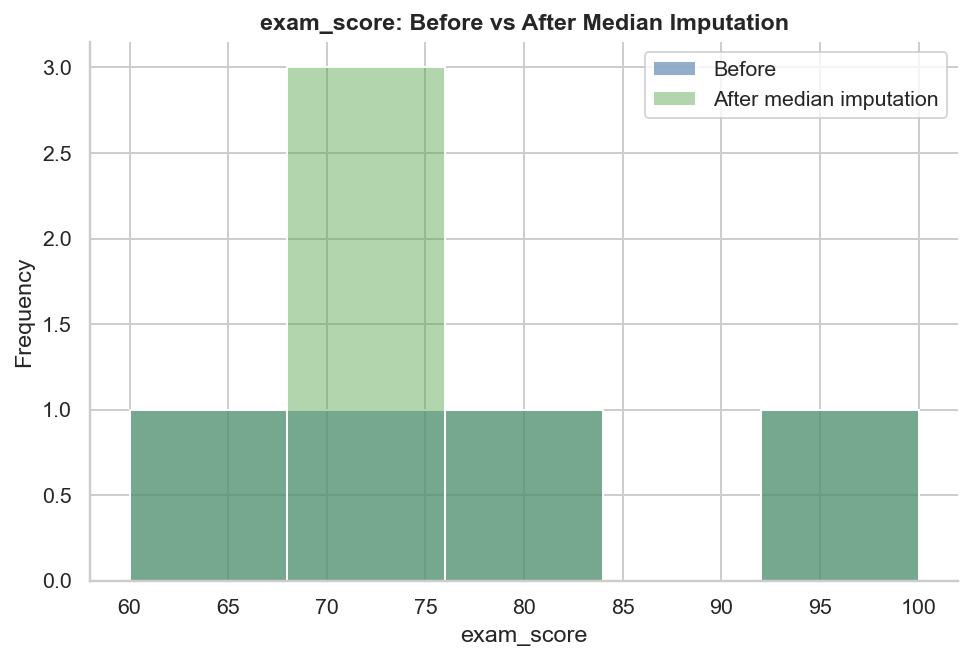

In [19]:
plt.figure(figsize=(8, 5), dpi=140)

sns.histplot(simple_df["exam_score"].dropna(), bins=5, color="#4C78A8", alpha=0.60, label="Before")
sns.histplot(simple_median["exam_score"], bins=5, color="#54A24B", alpha=0.45, label="After median imputation")

plt.title("exam_score: Before vs After Median Imputation")
plt.xlabel("exam_score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Section C — Mode Imputation

Mode imputation replaces missing values with the most frequent value.

This is especially useful for categorical variables.

In [20]:
simple_mode = simple_df.copy()

mode_imputer = SimpleImputer(strategy="most_frequent")
simple_mode[categorical_columns_simple] = mode_imputer.fit_transform(simple_mode[categorical_columns_simple])

simple_mode

,student,study_hours,exam_score,participation
0,Ana,2.0,60.0,High
1,Ben,4.0,70.0,Medium
2,Clara,NaN,80.0,High
3,David,6.0,NaN,Medium
4,Emma,8.0,100.0,High
5,Felix,NaN,NaN,High


In [21]:
print("Original participation values:")
print(simple_df["participation"].value_counts(dropna=False))

print("\nAfter mode imputation:")
print(simple_mode["participation"].value_counts(dropna=False))

Original participation values:
participation
High      2
Medium    2
NaN       2
Name: count, dtype: int64

After mode imputation:
participation
High      4
Medium    2
Name: count, dtype: int64


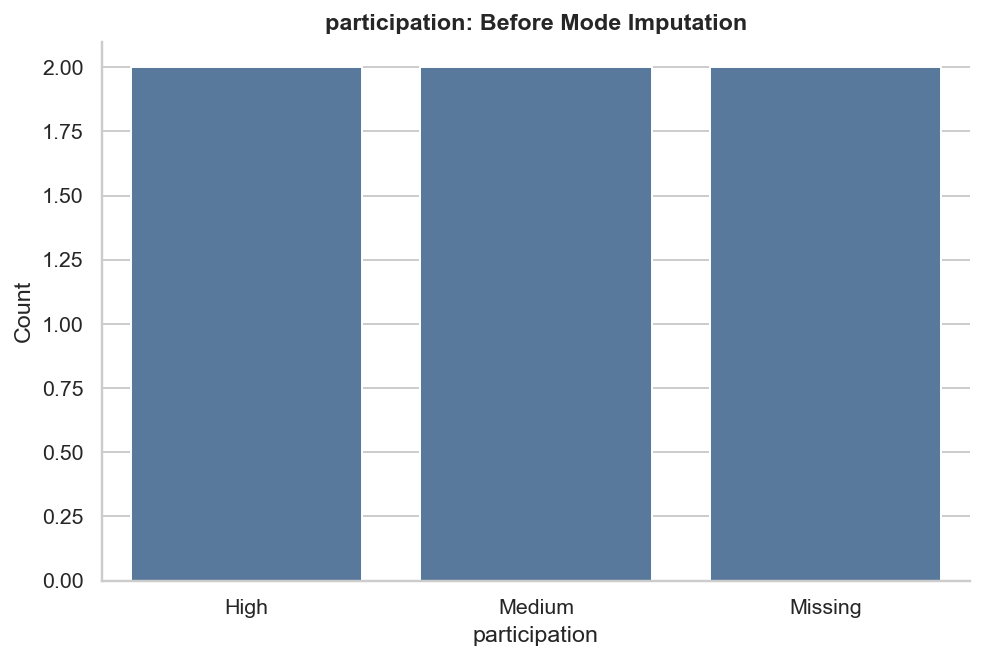

In [22]:
plt.figure(figsize=(8, 5), dpi=140)

order_before = simple_df["participation"].fillna("Missing")
sns.countplot(
    x=order_before,
    color="#4C78A8",
)

plt.title("participation: Before Mode Imputation")
plt.xlabel("participation")
plt.ylabel("Count")
plt.show()

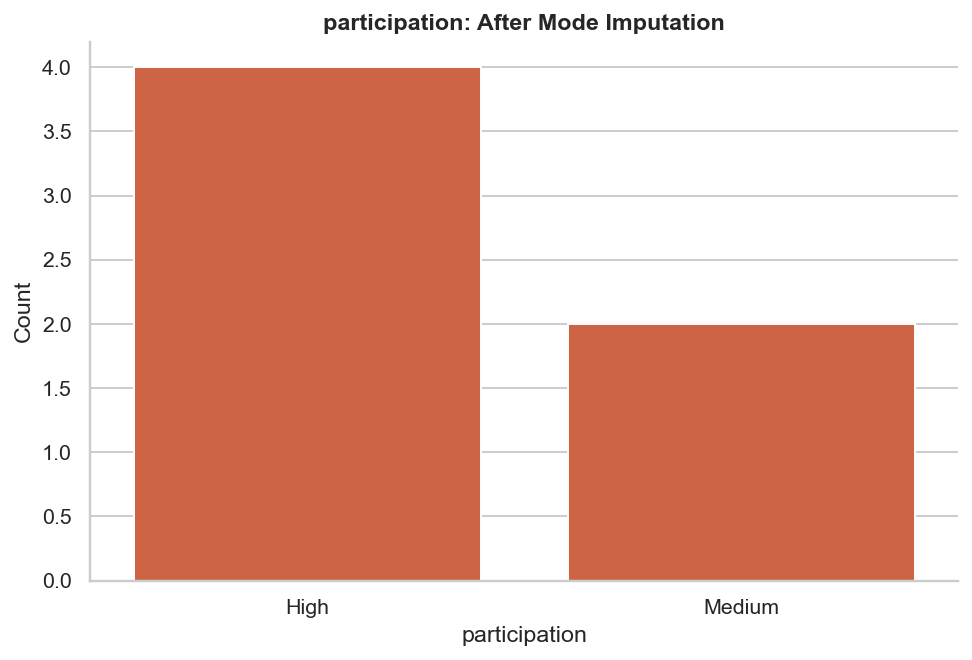

In [23]:
plt.figure(figsize=(8, 5), dpi=140)

sns.countplot(
    x=simple_mode["participation"],
    color="#E4572E",
)

plt.title("participation: After Mode Imputation")
plt.xlabel("participation")
plt.ylabel("Count")
plt.show()

# Section D — KNN Imputation

KNN imputation uses similar rows to estimate missing values.

Important practical point:

KNN uses distances. Therefore, numeric columns should be scaled before applying KNN.

In [24]:
simple_knn = simple_df.copy()

# KNN only works with numeric data.
# We use the numeric columns from the simple dataset.
numeric_data = simple_knn[numeric_columns_simple]

# Step 1: scale numeric values
scaler = StandardScaler()
numeric_data_scaled = scaler.fit_transform(numeric_data)

# Step 2: apply KNN imputation on scaled data
knn_imputer = KNNImputer(n_neighbors=2)
numeric_data_knn_scaled = knn_imputer.fit_transform(numeric_data_scaled)

# Step 3: transform back to original scale
numeric_data_knn = scaler.inverse_transform(numeric_data_knn_scaled)

# Step 4: place imputed numeric values back into the dataset
simple_knn[numeric_columns_simple] = numeric_data_knn

simple_knn

,student,study_hours,exam_score,participation
0,Ana,2.0,60.0,High
1,Ben,4.0,70.0,Medium
2,Clara,3.0,80.0,NaN
3,David,6.0,85.0,Medium
4,Emma,8.0,100.0,High
5,Felix,5.0,77.5,NaN


In [25]:
knn_metrics = pd.DataFrame({
    "missing_before": simple_df[numeric_columns_simple].isna().sum(),
    "missing_after": simple_knn[numeric_columns_simple].isna().sum(),
    "mean_before": simple_df[numeric_columns_simple].mean(),
    "mean_after": simple_knn[numeric_columns_simple].mean(),
    "variance_before": simple_df[numeric_columns_simple].var(),
    "variance_after": simple_knn[numeric_columns_simple].var(),
})

knn_metrics

,missing_before,missing_after,mean_before,mean_after,variance_before,variance_after
study_hours,2,0,5.0,4.666667,6.666667,4.666667
exam_score,2,0,77.5,78.750000,291.666667,184.375000


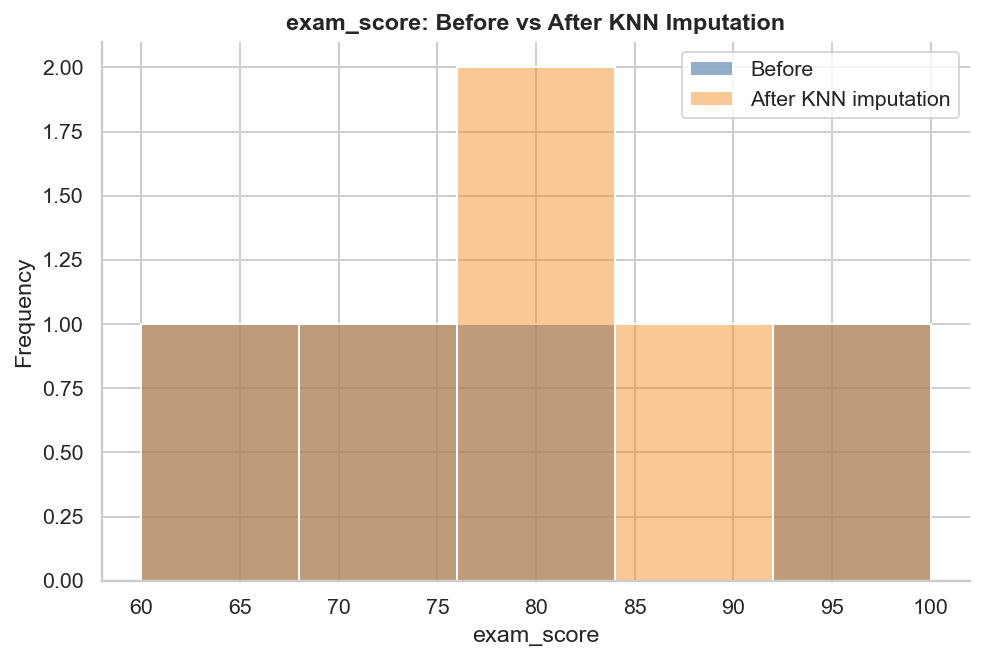

In [26]:
plt.figure(figsize=(8, 5), dpi=140)

sns.histplot(simple_df["exam_score"].dropna(), bins=5, color="#4C78A8", alpha=0.60, label="Before")
sns.histplot(simple_knn["exam_score"], bins=5, color="#F58518", alpha=0.45, label="After KNN imputation")

plt.title("exam_score: Before vs After KNN Imputation")
plt.xlabel("exam_score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Section E — MICE-style Iterative Imputation

MICE means **Multivariate Imputation by Chained Equations**.

In this notebook, we use scikit-learn's `IterativeImputer` as a simplified, classroom-friendly approximation.

The idea is:

1. Start with simple initial guesses  
2. Use relationships between variables  
3. Iteratively improve the imputed values

In [27]:
simple_mice = simple_df.copy()

mice_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    initial_strategy="mean",
)

simple_mice[numeric_columns_simple] = mice_imputer.fit_transform(simple_mice[numeric_columns_simple])

simple_mice

,student,study_hours,exam_score,participation
0,Ana,2.000000,60.000000,High
1,Ben,4.000000,70.000000,Medium
2,Clara,5.158569,80.000000,NaN
3,David,6.000000,85.690501,Medium
4,Emma,8.000000,100.000000,High
5,Felix,5.031714,79.138100,NaN


In [28]:
mice_metrics = pd.DataFrame({
    "missing_before": simple_df[numeric_columns_simple].isna().sum(),
    "missing_after": simple_mice[numeric_columns_simple].isna().sum(),
    "mean_before": simple_df[numeric_columns_simple].mean(),
    "mean_after": simple_mice[numeric_columns_simple].mean(),
    "variance_before": simple_df[numeric_columns_simple].var(),
    "variance_after": simple_mice[numeric_columns_simple].var(),
})

mice_metrics

,missing_before,missing_after,mean_before,mean_after,variance_before,variance_after
study_hours,2,0,5.0,5.031714,6.666667,4.004023
exam_score,2,0,77.5,79.138100,291.666667,185.733490


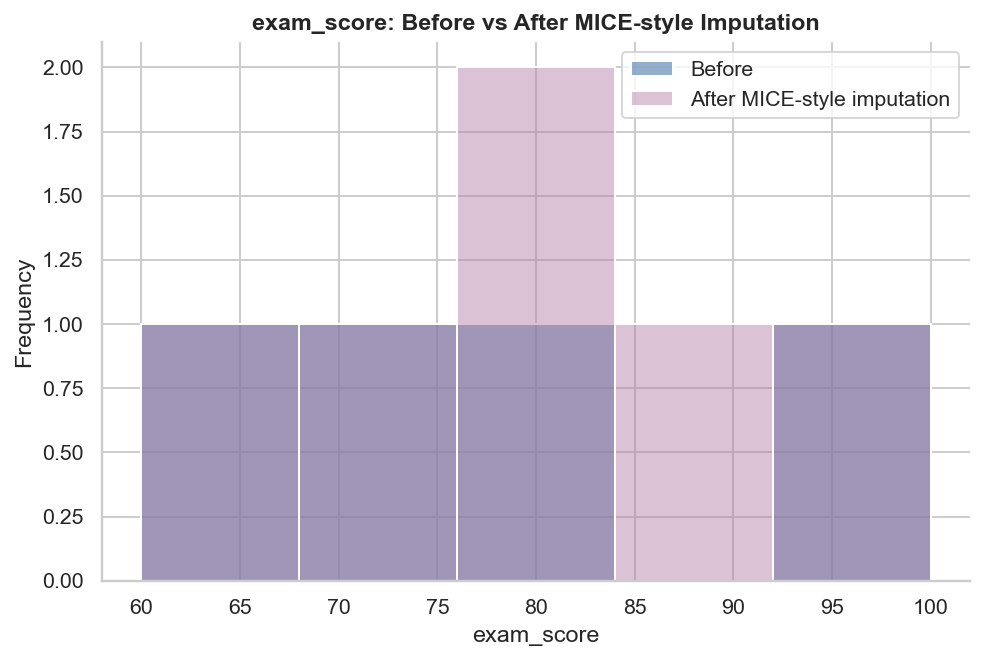

In [29]:
plt.figure(figsize=(8, 5), dpi=140)

sns.histplot(simple_df["exam_score"].dropna(), bins=5, color="#4C78A8", alpha=0.60, label="Before")
sns.histplot(simple_mice["exam_score"], bins=5, color="#B279A2", alpha=0.45, label="After MICE-style imputation")

plt.title("exam_score: Before vs After MICE-style Imputation")
plt.xlabel("exam_score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Section F — Compare Methods on the Simple Dataset

Now we compare how the different methods affect the same numeric columns.

In [30]:
method_comparison_simple = pd.DataFrame({
    "original_variance": simple_df[numeric_columns_simple].var(),
    "mean_imputation_variance": simple_mean[numeric_columns_simple].var(),
    "median_imputation_variance": simple_median[numeric_columns_simple].var(),
    "knn_imputation_variance": simple_knn[numeric_columns_simple].var(),
    "mice_style_imputation_variance": simple_mice[numeric_columns_simple].var(),
})

method_comparison_simple

,original_variance,mean_imputation_variance,median_imputation_variance,knn_imputation_variance,mice_style_imputation_variance
study_hours,6.666667,4.0,4.000000,4.666667,4.004023
exam_score,291.666667,175.0,176.666667,184.375000,185.733490


# Section G — Optional: Bank / Customer Dataset

Now we repeat the same logic with a more realistic dataset.

This dataset includes numeric and categorical variables such as:

- age  
- income  
- savings  
- loan amount  
- risk score  
- education  
- customer segment

In [31]:
bank_df = pd.read_csv("data/bank_customers_missing_values_sample.csv")

bank_df.head()

,customer_id,age,experience_years,education,income,savings,loan_amount,risk_score,customer_segment
0,1,67,47,PhD,118039.03,NaN,37919.56,717.7,Premium
1,2,30,9,High school,47128.77,NaN,40184.53,675.5,Core
2,3,22,0,NaN,35127.79,5464.51,35229.94,729.2,Budget
3,4,56,30,Master,107151.59,4689.43,36115.79,701.1,Premium
4,5,41,19,Bachelor,60396.14,12263.96,33809.16,690.4,NaN


In [32]:
bank_missing_summary = pd.DataFrame({
    "missing_count": bank_df.isna().sum(),
    "missing_percent": bank_df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

bank_missing_summary

,missing_count,missing_percent
savings,39,15.6
income,26,10.4
education,21,8.4
risk_score,19,7.6
customer_segment,15,6.0
customer_id,0,0.0
experience_years,0,0.0
age,0,0.0
loan_amount,0,0.0


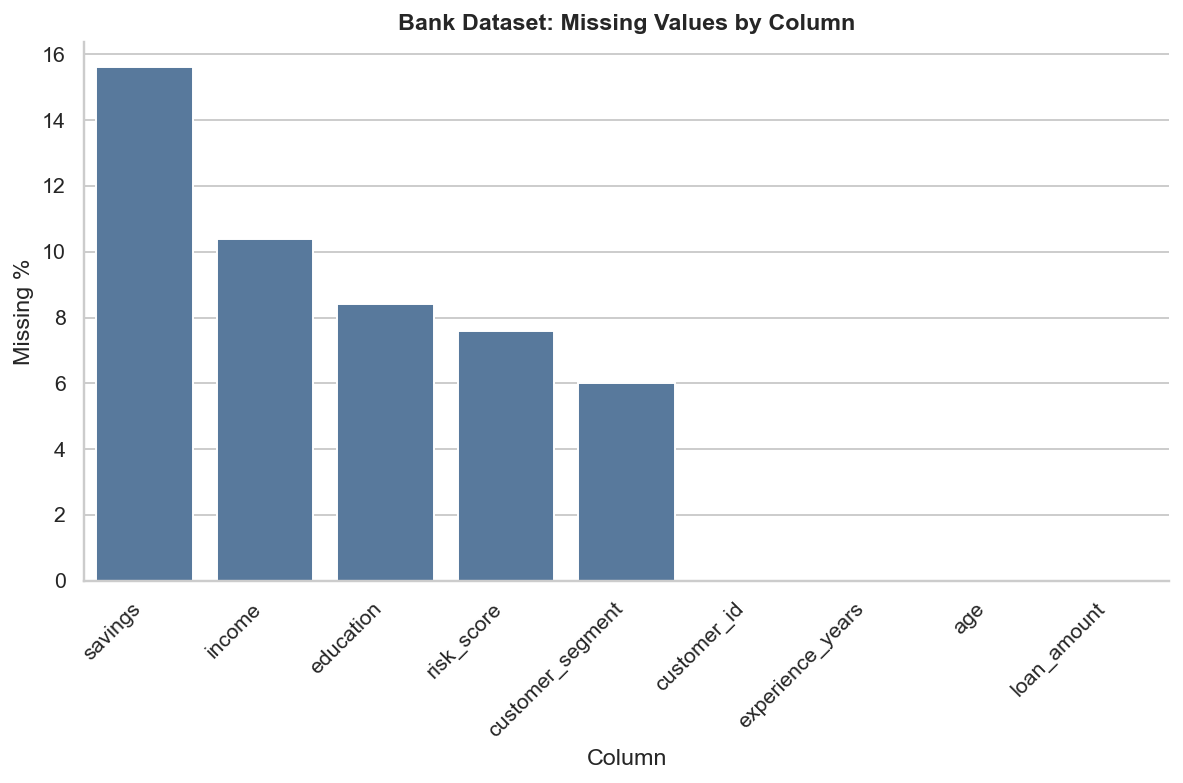

In [33]:
plt.figure(figsize=(10, 5), dpi=140)

sns.barplot(
    data=bank_missing_summary.reset_index().rename(columns={"index": "column"}),
    x="column",
    y="missing_percent",
    color="#4C78A8",
)

plt.title("Bank Dataset: Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.show()

In [34]:
numeric_columns_bank = bank_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns_bank = [col for col in bank_df.columns if col not in numeric_columns_bank]

print("Numeric columns:", numeric_columns_bank)
print("Categorical columns:", categorical_columns_bank)

Numeric columns: ['customer_id', 'age', 'experience_years', 'income', 'savings', 'loan_amount', 'risk_score']
Categorical columns: ['education', 'customer_segment']


## Bank dataset: correlation heatmap before imputation

Correlation heatmaps help us inspect relationships between numeric variables.

After imputation, we can compare whether the relationship structure changed.

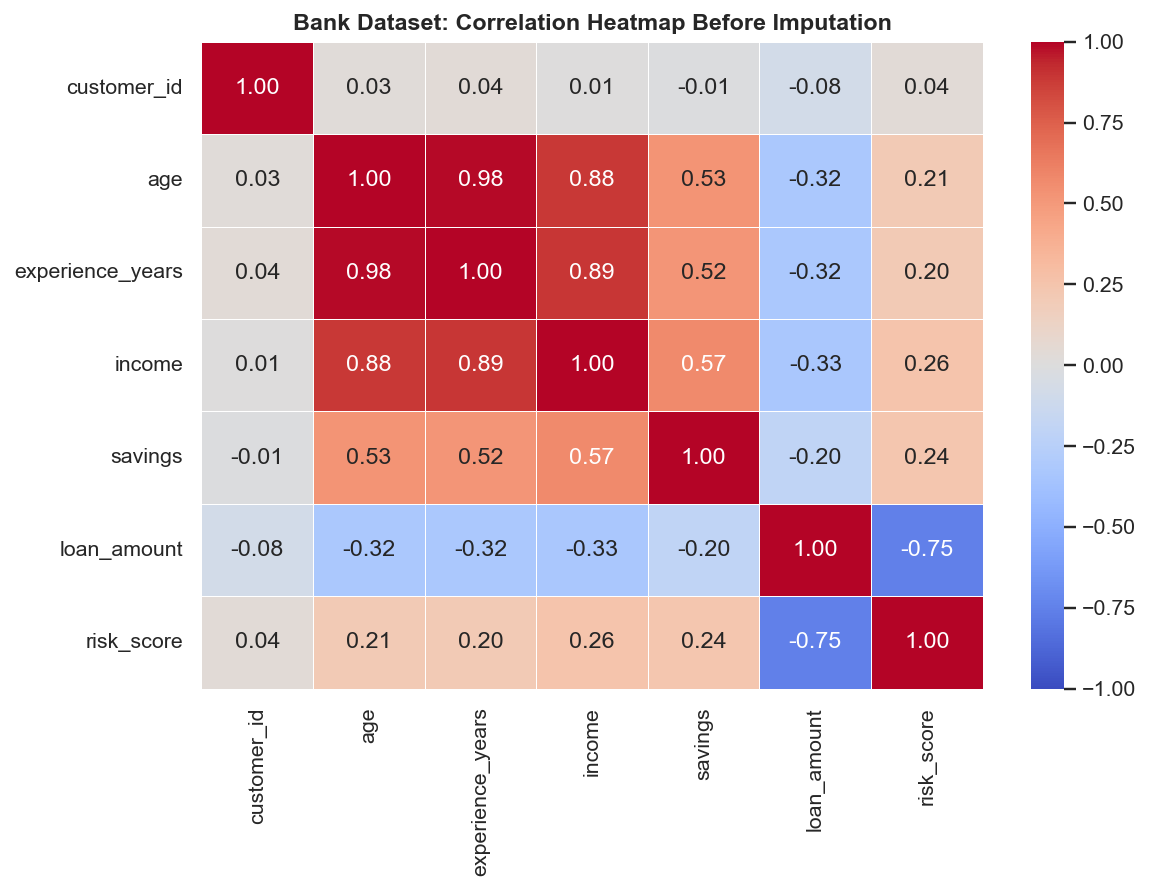

In [35]:
plt.figure(figsize=(9, 6), dpi=140)

corr_before = bank_df[numeric_columns_bank].corr()

sns.heatmap(
    corr_before,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Bank Dataset: Correlation Heatmap Before Imputation")
plt.show()

## Bank dataset: mean + mode imputation

For the bank dataset:

- Numeric columns are filled with the mean
- Categorical columns are filled with the mode

In [36]:
bank_mean_mode = bank_df.copy()

numeric_imputer = SimpleImputer(strategy="mean")
categorical_imputer = SimpleImputer(strategy="most_frequent")

bank_mean_mode[numeric_columns_bank] = numeric_imputer.fit_transform(bank_mean_mode[numeric_columns_bank])
bank_mean_mode[categorical_columns_bank] = categorical_imputer.fit_transform(bank_mean_mode[categorical_columns_bank].astype("object"))

bank_mean_mode.head()

,customer_id,age,experience_years,education,income,savings,loan_amount,risk_score,customer_segment
0,1.0,67.0,47.0,PhD,118039.03,10425.978578,37919.56,717.7,Premium
1,2.0,30.0,9.0,High school,47128.77,10425.978578,40184.53,675.5,Core
2,3.0,22.0,0.0,Bachelor,35127.79,5464.510000,35229.94,729.2,Budget
3,4.0,56.0,30.0,Master,107151.59,4689.430000,36115.79,701.1,Premium
4,5.0,41.0,19.0,Bachelor,60396.14,12263.960000,33809.16,690.4,Premium


In [37]:
bank_mean_metrics = pd.DataFrame({
    "missing_before": bank_df[numeric_columns_bank].isna().sum(),
    "missing_after": bank_mean_mode[numeric_columns_bank].isna().sum(),
    "mean_before": bank_df[numeric_columns_bank].mean(),
    "mean_after": bank_mean_mode[numeric_columns_bank].mean(),
    "variance_before": bank_df[numeric_columns_bank].var(),
    "variance_after": bank_mean_mode[numeric_columns_bank].var(),
})

bank_mean_metrics

,missing_before,missing_after,mean_before,mean_after,variance_before,variance_after
customer_id,0,0,125.500000,125.500000,5.229167e+03,5.229167e+03
age,0,0,48.232000,48.232000,2.420423e+02,2.420423e+02
experience_years,0,0,24.204000,24.204000,2.376169e+02,2.376169e+02
income,26,0,81886.677679,81886.677679,7.442648e+08,6.665504e+08
savings,39,0,10425.978578,10425.978578,4.027898e+07,3.397022e+07
loan_amount,0,0,26832.087240,26832.087240,9.658594e+07,9.658594e+07
risk_score,19,0,730.520346,730.520346,2.578987e+03,2.382197e+03


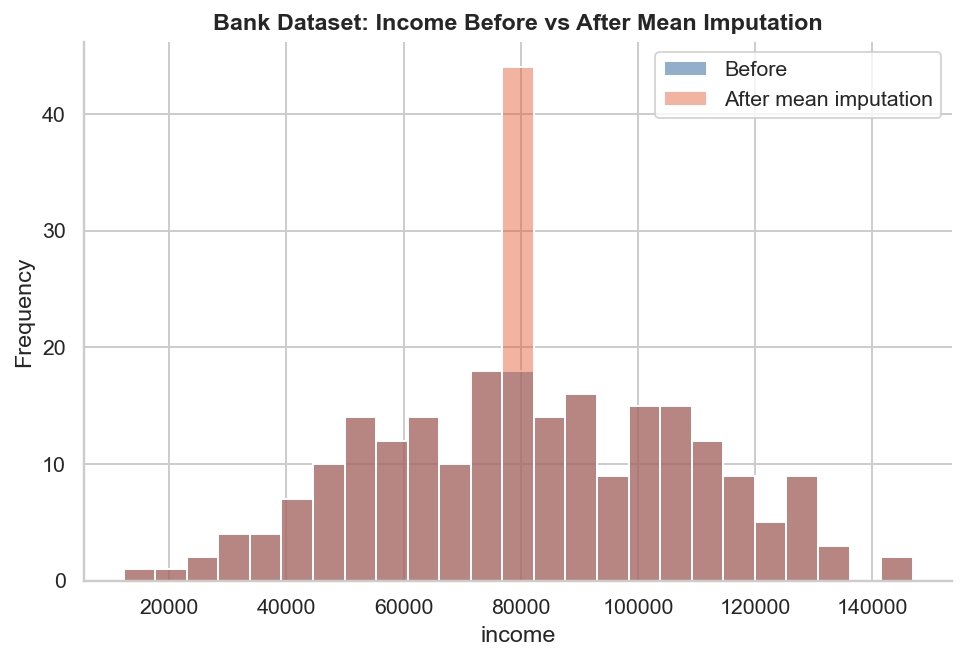

In [38]:
plt.figure(figsize=(8, 5), dpi=140)

sns.histplot(bank_df["income"].dropna(), bins=25, color="#4C78A8", alpha=0.60, label="Before")
sns.histplot(bank_mean_mode["income"], bins=25, color="#E4572E", alpha=0.45, label="After mean imputation")

plt.title("Bank Dataset: Income Before vs After Mean Imputation")
plt.xlabel("income")
plt.ylabel("Frequency")
plt.legend()
plt.show()

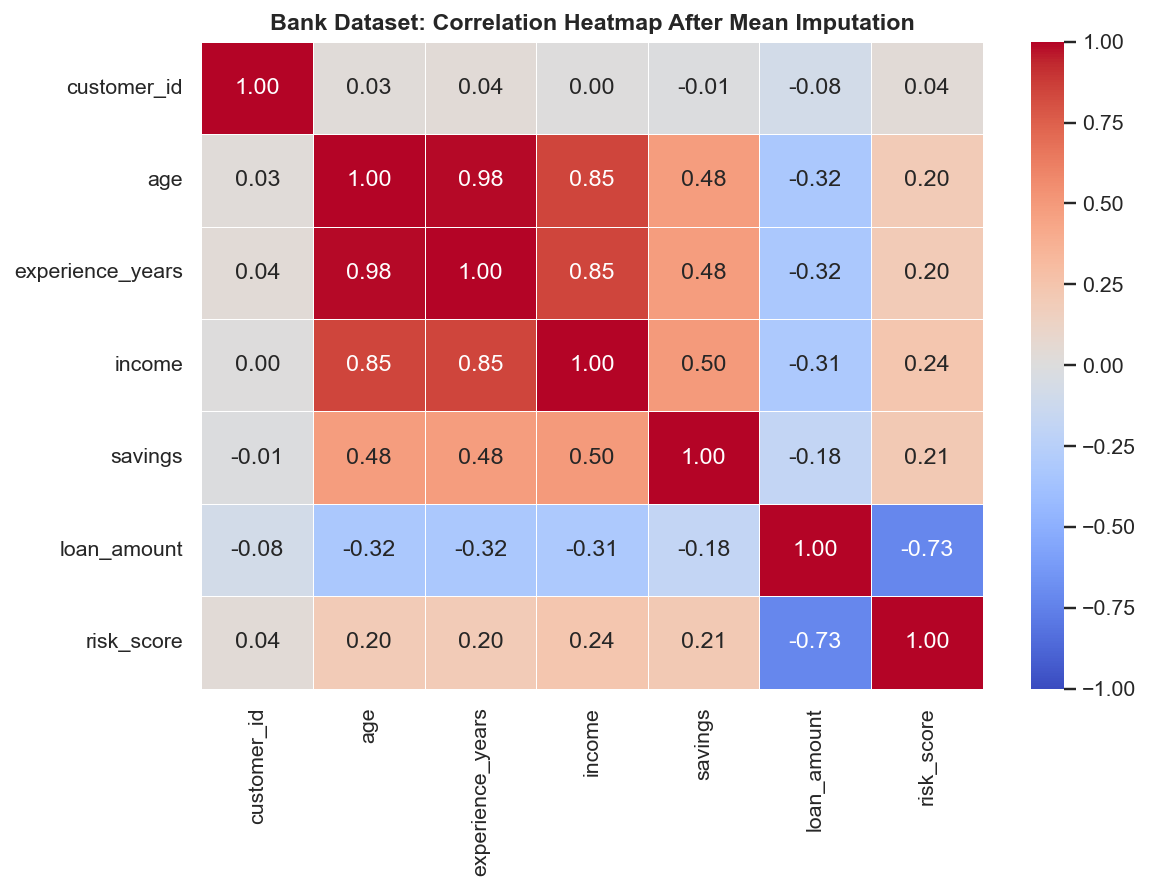

In [39]:
plt.figure(figsize=(9, 6), dpi=140)

corr_after_mean = bank_mean_mode[numeric_columns_bank].corr()

sns.heatmap(
    corr_after_mean,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Bank Dataset: Correlation Heatmap After Mean Imputation")
plt.show()

## Bank dataset: KNN + mode imputation

Here we use KNN for numeric variables and mode for categorical variables.

Again, we scale numeric variables before KNN because distance-based methods are sensitive to scale.

In [40]:
bank_knn_mode = bank_df.copy()

# Numeric KNN imputation
bank_numeric_data = bank_knn_mode[numeric_columns_bank]

bank_scaler = StandardScaler()
bank_numeric_scaled = bank_scaler.fit_transform(bank_numeric_data)

bank_knn_imputer = KNNImputer(n_neighbors=5)
bank_numeric_knn_scaled = bank_knn_imputer.fit_transform(bank_numeric_scaled)

bank_numeric_knn = bank_scaler.inverse_transform(bank_numeric_knn_scaled)
bank_knn_mode[numeric_columns_bank] = bank_numeric_knn

# Categorical mode imputation
bank_knn_mode[categorical_columns_bank] = categorical_imputer.fit_transform(bank_knn_mode[categorical_columns_bank].astype("object"))

bank_knn_mode.head()

,customer_id,age,experience_years,education,income,savings,loan_amount,risk_score,customer_segment
0,1.0,67.0,47.0,PhD,118039.03,10088.910,37919.56,717.7,Premium
1,2.0,30.0,9.0,High school,47128.77,8114.454,40184.53,675.5,Core
2,3.0,22.0,0.0,Bachelor,35127.79,5464.510,35229.94,729.2,Budget
3,4.0,56.0,30.0,Master,107151.59,4689.430,36115.79,701.1,Premium
4,5.0,41.0,19.0,Bachelor,60396.14,12263.960,33809.16,690.4,Premium


In [41]:
bank_knn_metrics = pd.DataFrame({
    "missing_before": bank_df[numeric_columns_bank].isna().sum(),
    "missing_after": bank_knn_mode[numeric_columns_bank].isna().sum(),
    "mean_before": bank_df[numeric_columns_bank].mean(),
    "mean_after": bank_knn_mode[numeric_columns_bank].mean(),
    "variance_before": bank_df[numeric_columns_bank].var(),
    "variance_after": bank_knn_mode[numeric_columns_bank].var(),
})

bank_knn_metrics

,missing_before,missing_after,mean_before,mean_after,variance_before,variance_after
customer_id,0,0,125.500000,125.500000,5.229167e+03,5.229167e+03
age,0,0,48.232000,48.232000,2.420423e+02,2.420423e+02
experience_years,0,0,24.204000,24.204000,2.376169e+02,2.376169e+02
income,26,0,81886.677679,81227.925736,7.442648e+08,7.166004e+08
savings,39,0,10425.978578,10550.314288,4.027898e+07,3.654166e+07
loan_amount,0,0,26832.087240,26832.087240,9.658594e+07,9.658594e+07
risk_score,19,0,730.520346,730.219520,2.578987e+03,2.455151e+03


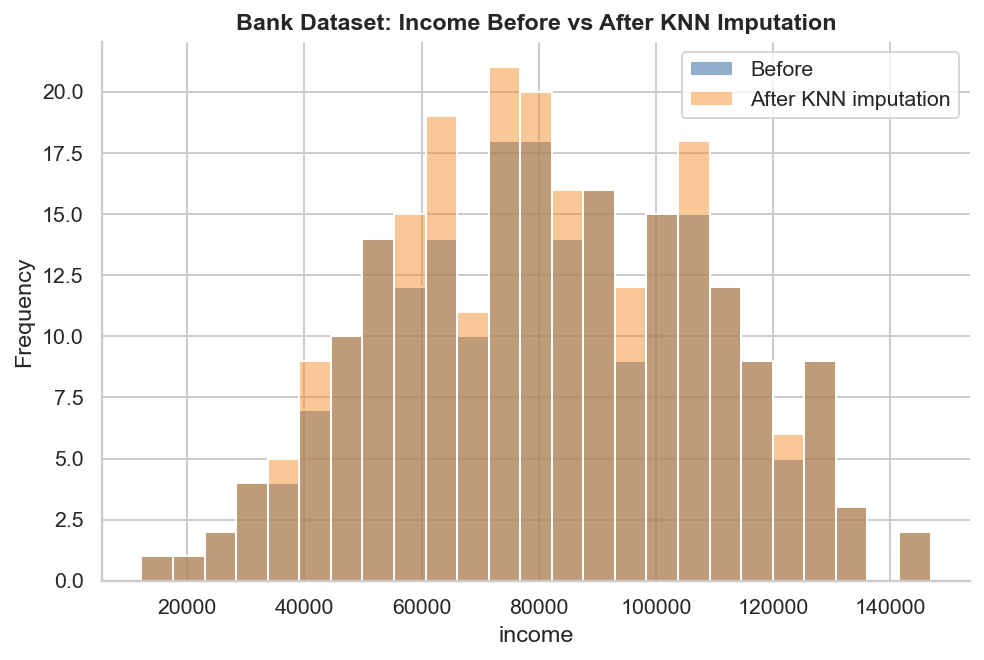

In [42]:
plt.figure(figsize=(8, 5), dpi=140)

sns.histplot(bank_df["income"].dropna(), bins=25, color="#4C78A8", alpha=0.60, label="Before")
sns.histplot(bank_knn_mode["income"], bins=25, color="#F58518", alpha=0.45, label="After KNN imputation")

plt.title("Bank Dataset: Income Before vs After KNN Imputation")
plt.xlabel("income")
plt.ylabel("Frequency")
plt.legend()
plt.show()

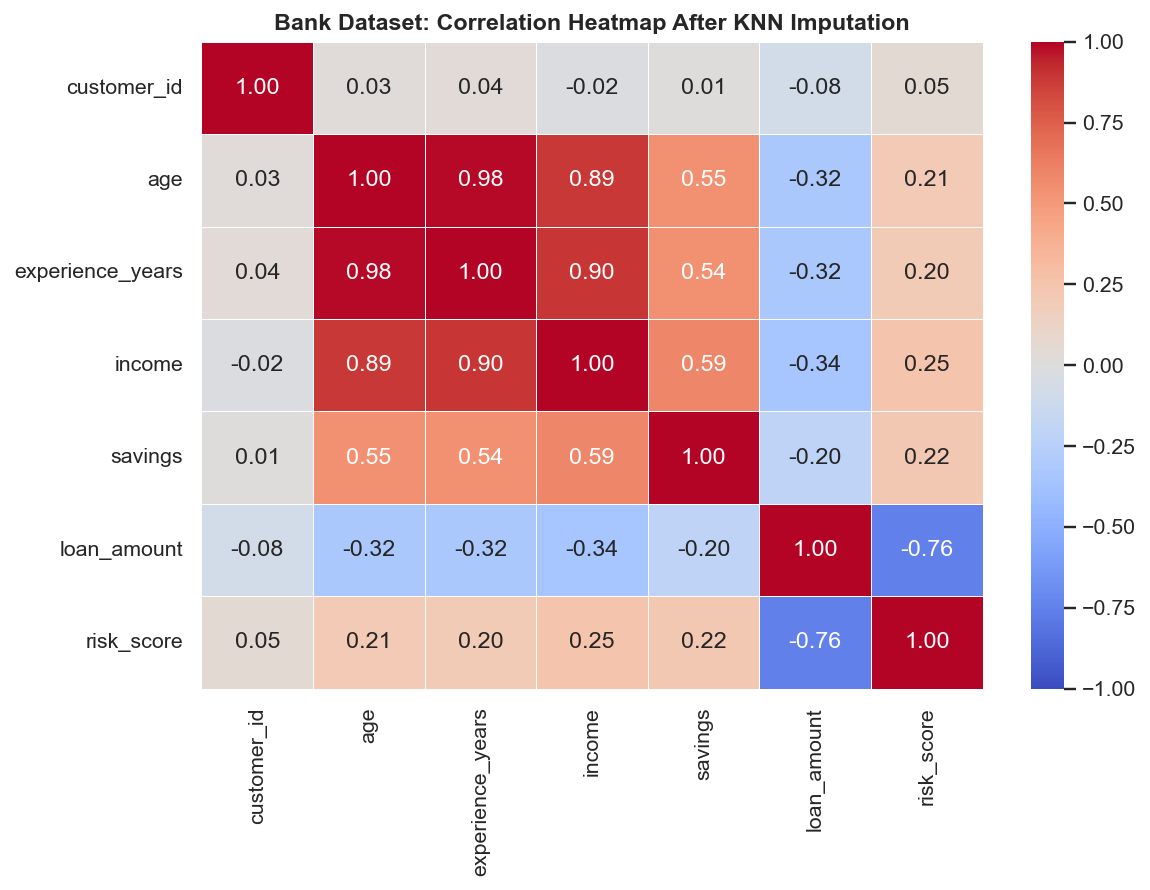

In [43]:
plt.figure(figsize=(9, 6), dpi=140)

corr_after_knn = bank_knn_mode[numeric_columns_bank].corr()

sns.heatmap(
    corr_after_knn,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Bank Dataset: Correlation Heatmap After KNN Imputation")
plt.show()

## Final discussion questions

1. Which method is easiest to understand?
2. Which method changes the variance the most?
3. Which method seems more realistic for the bank/customer dataset?
4. Why does KNN require scaling?
5. Why is MICE-style imputation more advanced than mean or median imputation?
6. When might imputation be risky?